In [2]:
from IPython.display import HTML
import re
import copy

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.patheffects as path_effects
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Polygon

import numpy as np
from scipy.special import binom
import itertools
import requests


from io import StringIO as sio
from io import BytesIO as csio

## set default matplotlib font and font size
typeface='helvetica'
mpl.rcParams['font.weight']=300
mpl.rcParams['axes.labelweight']=300
mpl.rcParams['font.family']=typeface
mpl.rcParams['font.size']=22

import os,random
from itertools import permutations


import sys
sys.path.append('/Users/nmueller/Documents/github/Plasmids-Material/Applications/Shigella2024/visualisation_code')
import baltic as bt



In [3]:
filenames = ['Sson_NC_007385_VP_over60.filtered95',
             'Sson_NC_009345_spA_over50.filtered80',
             'Sson_NC_009345_spA_over50.filtered90',
             'Sson_NC_009345_spA_over60.filtered80',
             'Sson_NC_009345_spA_over60.filtered90',
             'Sson_NC_009345_spA_over90.filtered95',
             'Sson_NC_009346_spB_over90.filtered95',
             'Sson_NC_009347_spC_over90.filtered95']

# colours={'NC_007384':(0.2981622478541206, 0.44644367598435458, 0.64719724652229571),
#         'NC_007385':"#E69F00",
#         'NC_009345':"#0072B2",
#         'NC_009346':"#009E73",
#         'NC_009347':"#D55E00"}

cmap=mpl.cm.viridis
cumulative_displace=0 ## this tracks the "current" x position, so trees are plotted one after another
path='/Users/nmueller/Documents/github/Plasmids-Material/Applications/Shigella2024/tangletrees/' ## path to trees
trees={} ## dict
# for each segment, load first the corresponding chromosome tree and then the plasmid tree
for filename in filenames:
    print(filename,)    
    # read in the corresponding chromosome tree
    tree_path=os.path.join(path, filename+'_chromosome_divergence_tree.nexus') ## path to tree
    trees[filename+'_chromosome']=bt.loadNewick(tree_path, absoluteTime=False) ## load tree

    tree_path=os.path.join(path, filename+'_divergence_tree.nexus') ## path to tree
    print(tree_path,)
    trees[filename]=bt.loadNewick(tree_path, absoluteTime=False) ## load tree

print('\nDone!')


Sson_NC_007385_VP_over60.filtered95
/Users/nmueller/Documents/github/Plasmids-Material/Applications/Shigella2024/tangletrees/Sson_NC_007385_VP_over60.filtered95_divergence_tree.nexus
Sson_NC_009345_spA_over50.filtered80
/Users/nmueller/Documents/github/Plasmids-Material/Applications/Shigella2024/tangletrees/Sson_NC_009345_spA_over50.filtered80_divergence_tree.nexus
Sson_NC_009345_spA_over50.filtered90
/Users/nmueller/Documents/github/Plasmids-Material/Applications/Shigella2024/tangletrees/Sson_NC_009345_spA_over50.filtered90_divergence_tree.nexus
Sson_NC_009345_spA_over60.filtered80
/Users/nmueller/Documents/github/Plasmids-Material/Applications/Shigella2024/tangletrees/Sson_NC_009345_spA_over60.filtered80_divergence_tree.nexus
Sson_NC_009345_spA_over60.filtered90
/Users/nmueller/Documents/github/Plasmids-Material/Applications/Shigella2024/tangletrees/Sson_NC_009345_spA_over60.filtered90_divergence_tree.nexus
Sson_NC_009345_spA_over90.filtered95
/Users/nmueller/Documents/github/Plasmid

In [4]:
# for each chromsome plasmid pair, untangle the trees
for filename in filenames:
    tip_positions={x:{} for x in trees} ## remember the position of each tip in each tree

    for t,tr in enumerate(trees.keys()): ## iterate over trees
        cur_tree=trees[tr] ## fetch tree object
        for k in cur_tree.Objects:
            if k.branchType=='leaf':
                tip_positions[tr][k.name]=(k.height,k.y) ## remember (X, Y) position of tip

    cmap=mpl.cm.Spectral
    for X in range(10): ## 10 untangling iterations
        print('iteration %d'%(X+1))
        # iterate over every chromosome plastid pair
        ptr=filename+'_chromosome'
        ntr=filename
        seg=trees[ptr]
        nex_seg=trees[ntr]

        for k in sorted(nex_seg.Objects,key=lambda q:q.height): ## iterate over branches from most recent to oldest
            if k.branchType=='node':
                leaves=[w.leaves if w.branchType=='node' else [w.name] for w in k.children]
                for c in range(len(leaves)):
                    leaves[c]=sorted(leaves[c],key=lambda x:tip_positions[ntr][x][1] if x in tip_positions[ntr] else 0.0)
                ys=[sorted([tip_positions[ntr][w][1] for w in cl if w in tip_positions[ntr]]) for cl in leaves]
                merge_ys=sum(ys,[])
                ypos=range(int(min(merge_ys)),int(max(merge_ys))+1)
                order={i:x for i,x in enumerate(leaves)}
                new_order=sorted(order.keys(),key=lambda x:-np.mean([(tip_positions[ptr][order[x][w]][1]-ypos[w]) for w in range(min([len(order[x]),len(ypos)])) if order[x][w] in tip_positions[ptr]]))
                if new_order!=range(len(leaves)):
                    k.children=[k.children[i] for i in new_order]
                    nex_seg.drawTree()
                    for w in nex_seg.Objects:
                        if w.branchType=='leaf':
                            tip_positions[ntr][w.name]=(w.height,w.y)

        if t==0:
            trees[filename].drawTree()
            lvs=sorted([w for w in trees[filename].Objects if w.branchType=='leaf'],key=lambda x:x.y)
            norm=mpl.colors.Normalize(0,len(lvs))
            pos_colours={w.name:cmap(norm(w.y)) for w in lvs}



iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9
iteration 10


Sson_NC_007385_VP_over60.filtered95


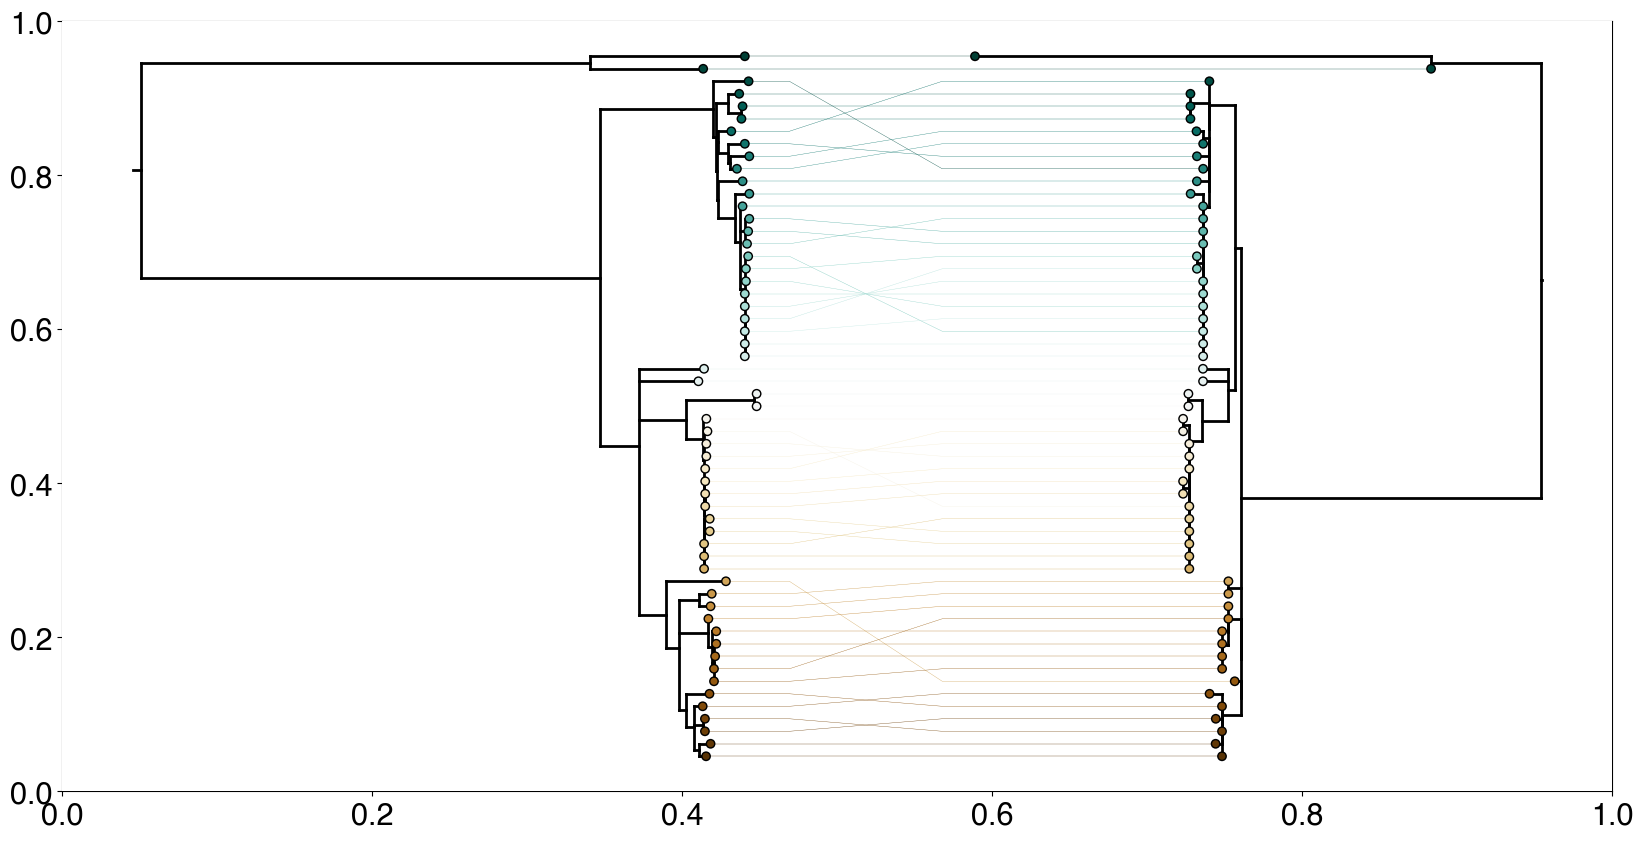

Sson_NC_009345_spA_over50.filtered80


<Figure size 640x480 with 0 Axes>

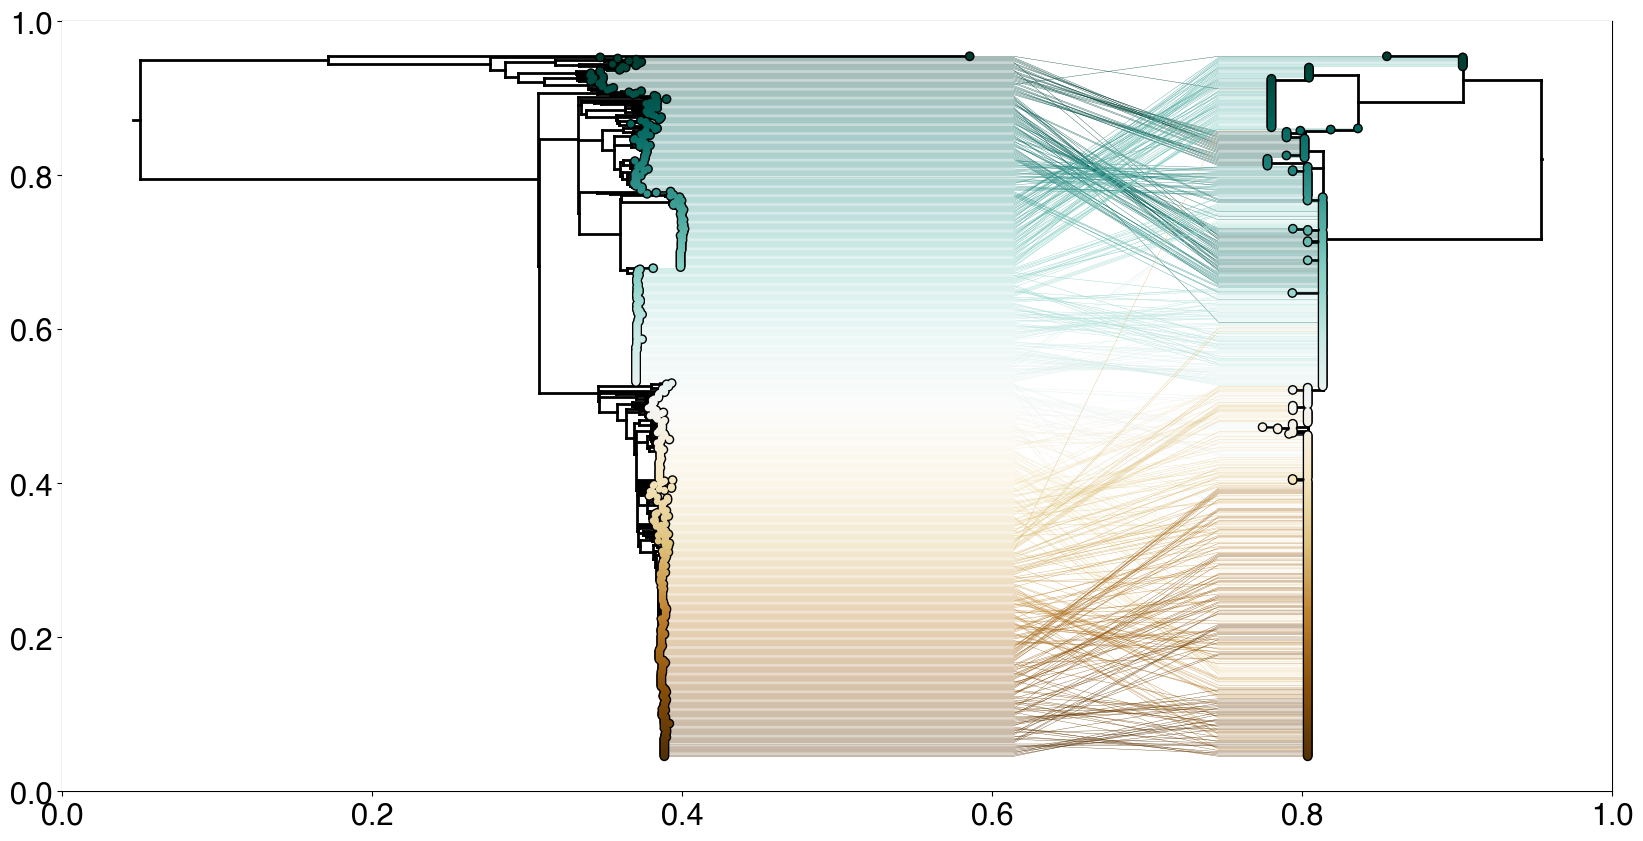

Sson_NC_009345_spA_over50.filtered90


<Figure size 640x480 with 0 Axes>

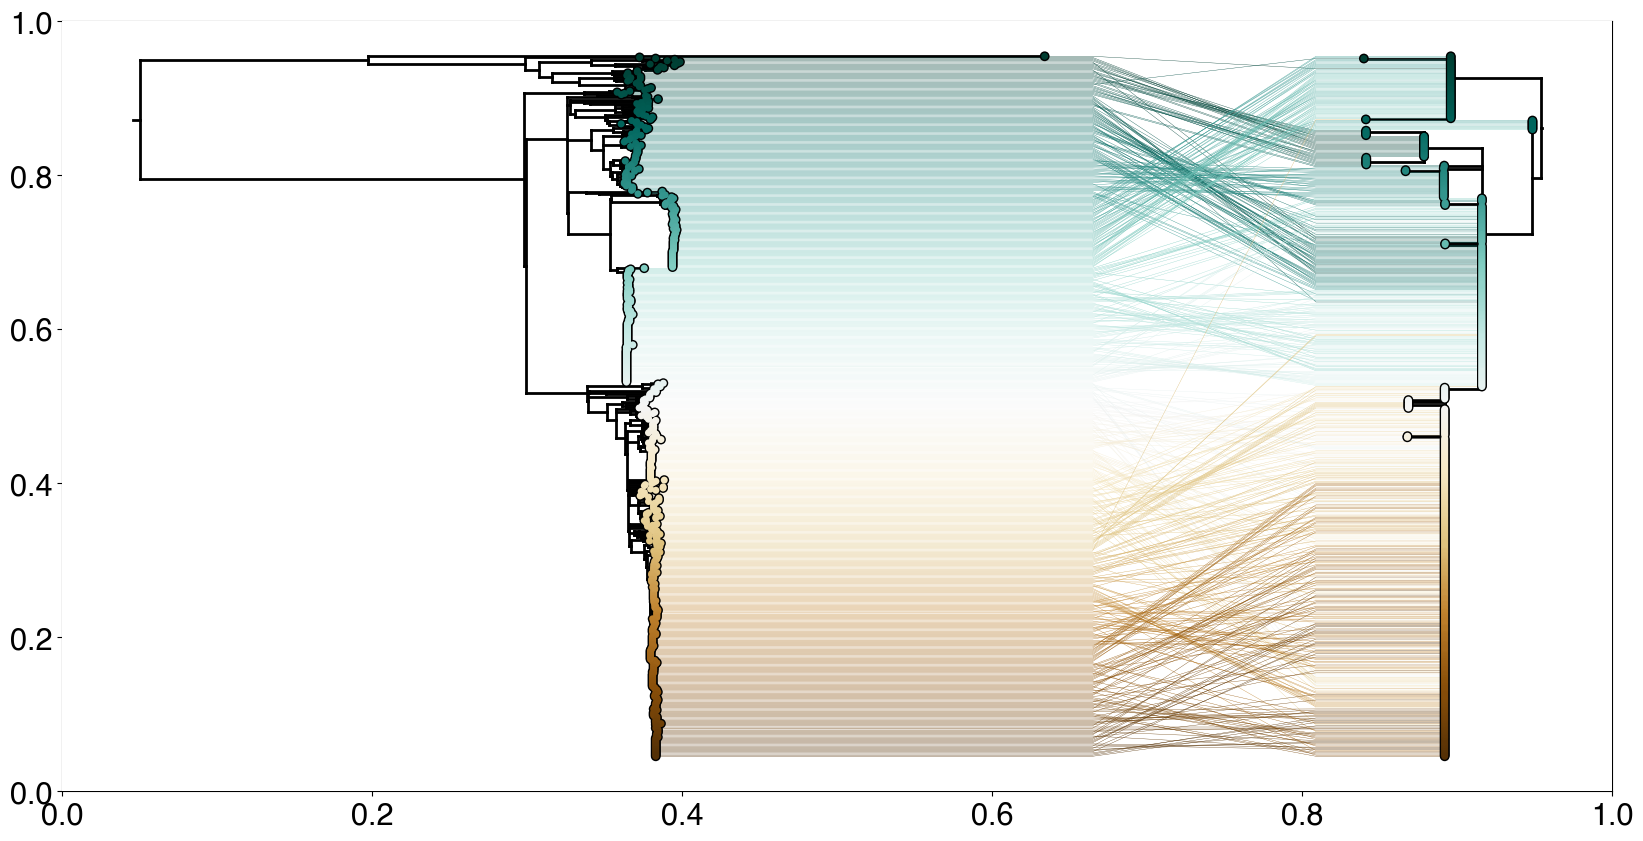

Sson_NC_009345_spA_over60.filtered80


<Figure size 640x480 with 0 Axes>

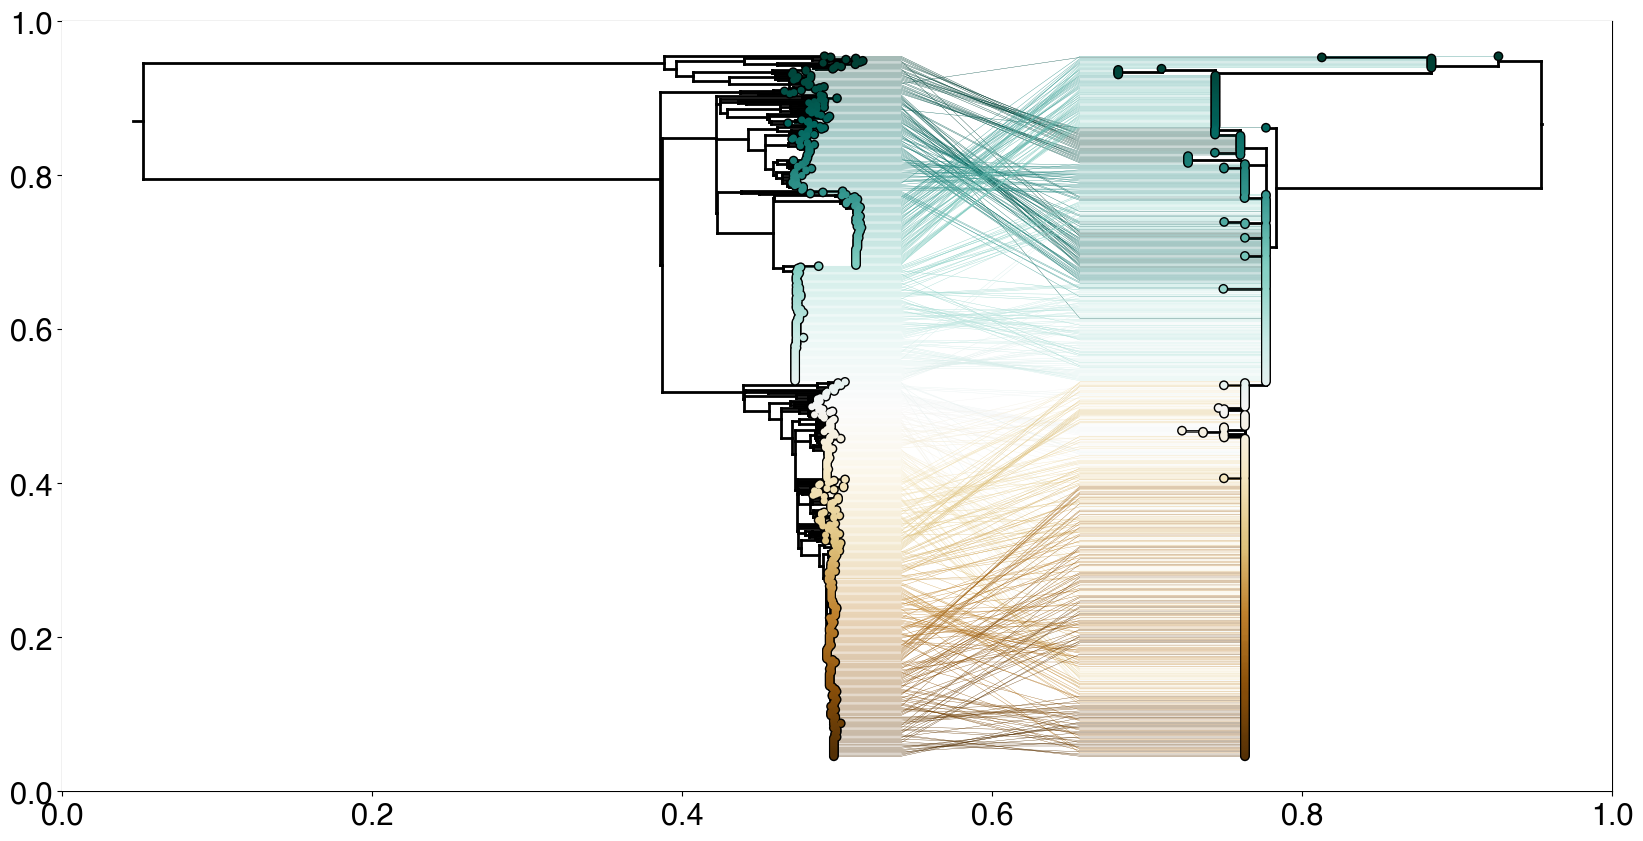

Sson_NC_009345_spA_over60.filtered90


<Figure size 640x480 with 0 Axes>

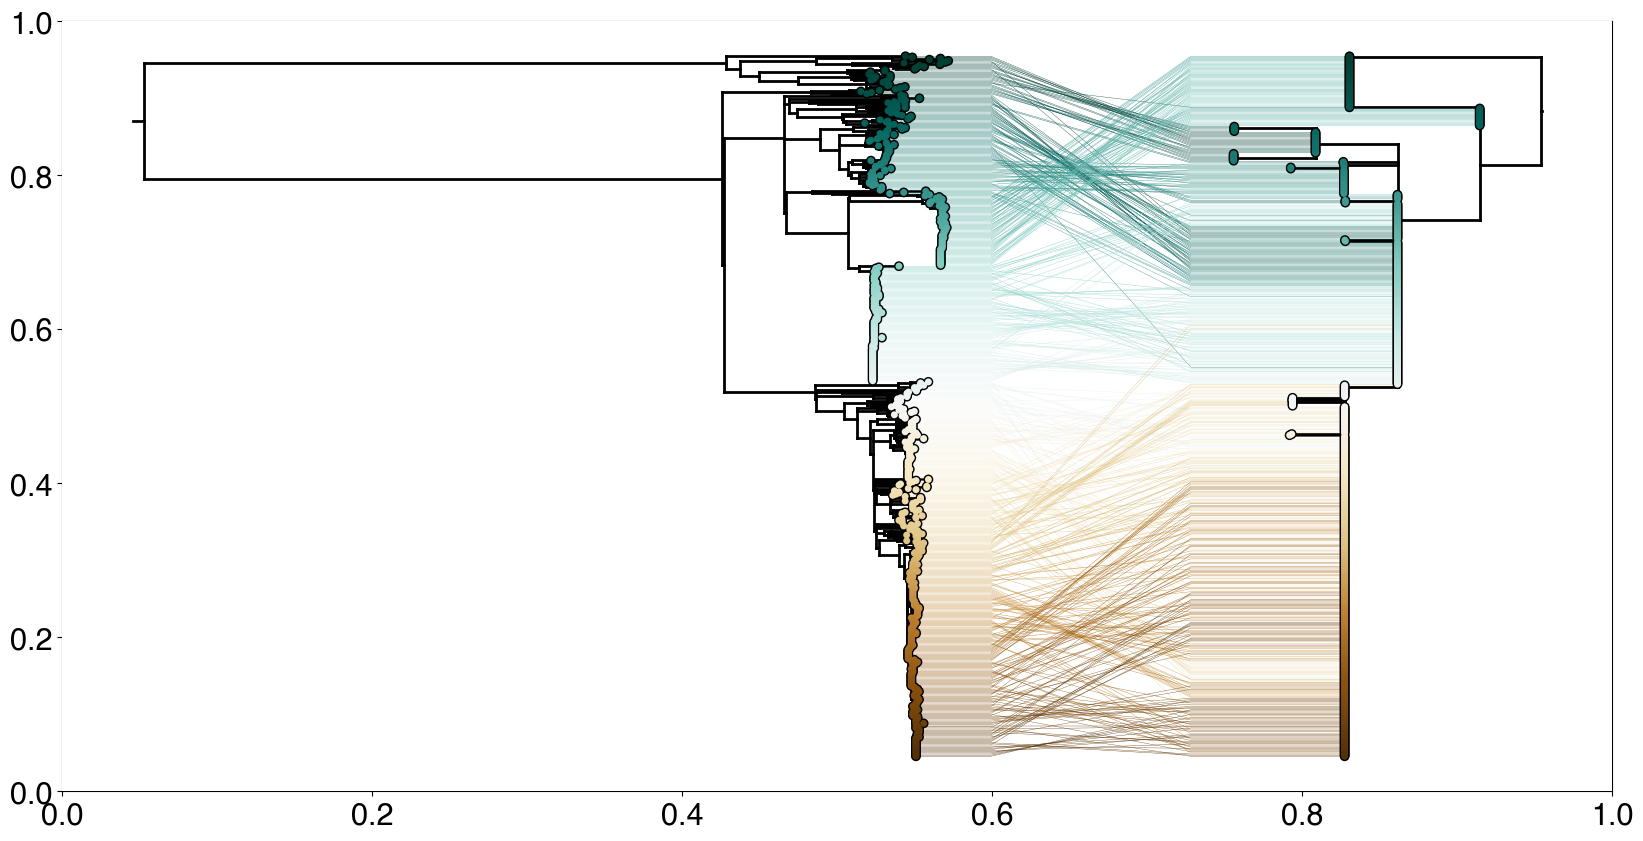

Sson_NC_009345_spA_over90.filtered95


<Figure size 640x480 with 0 Axes>

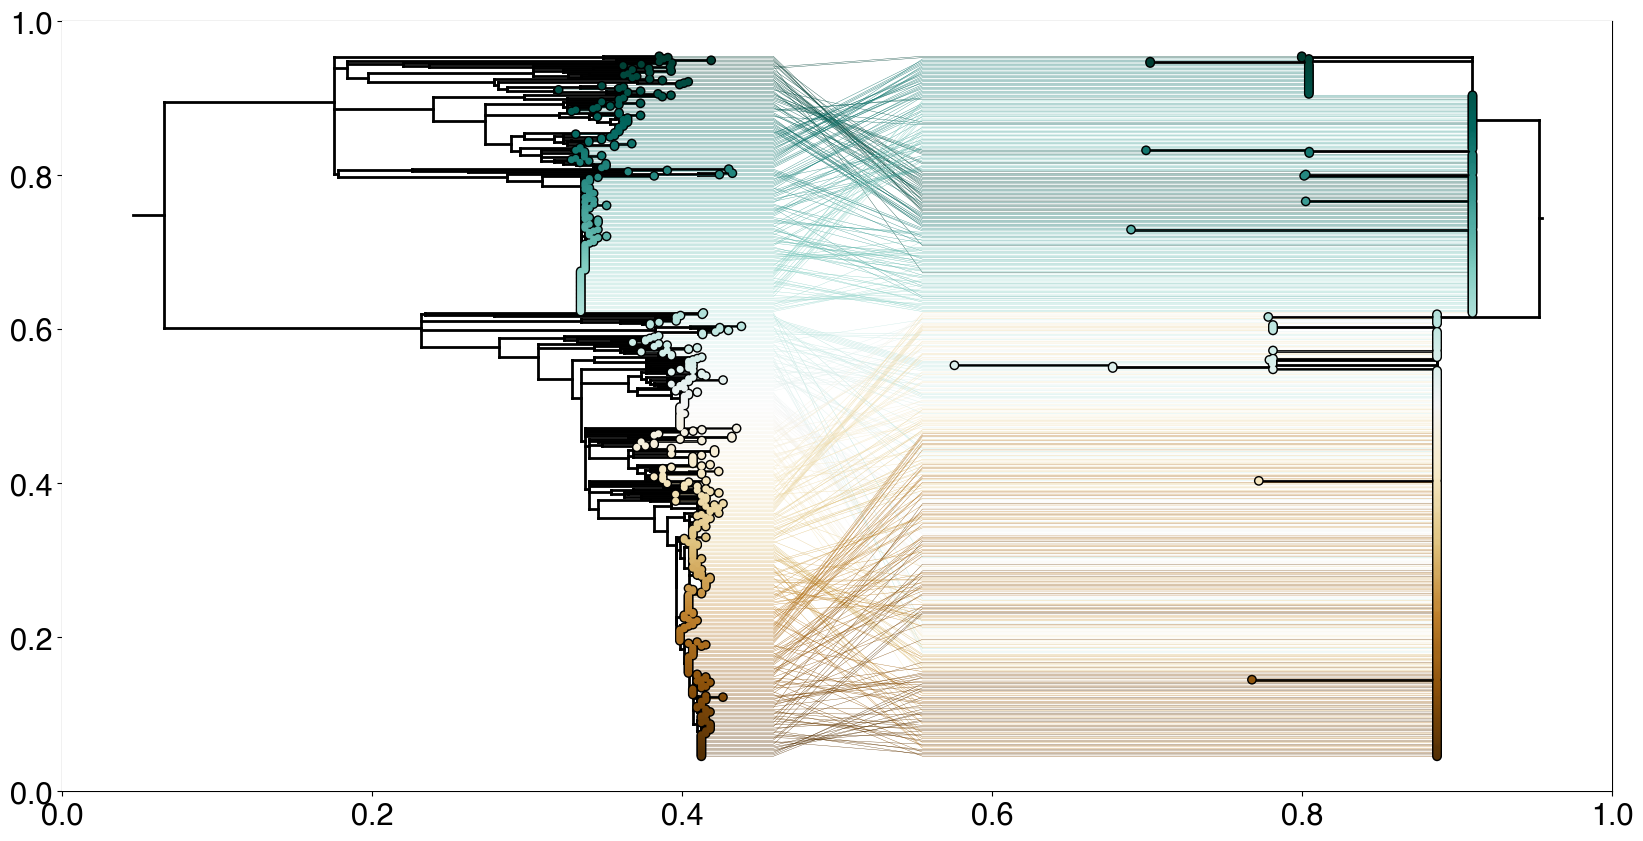

Sson_NC_009346_spB_over90.filtered95


<Figure size 640x480 with 0 Axes>

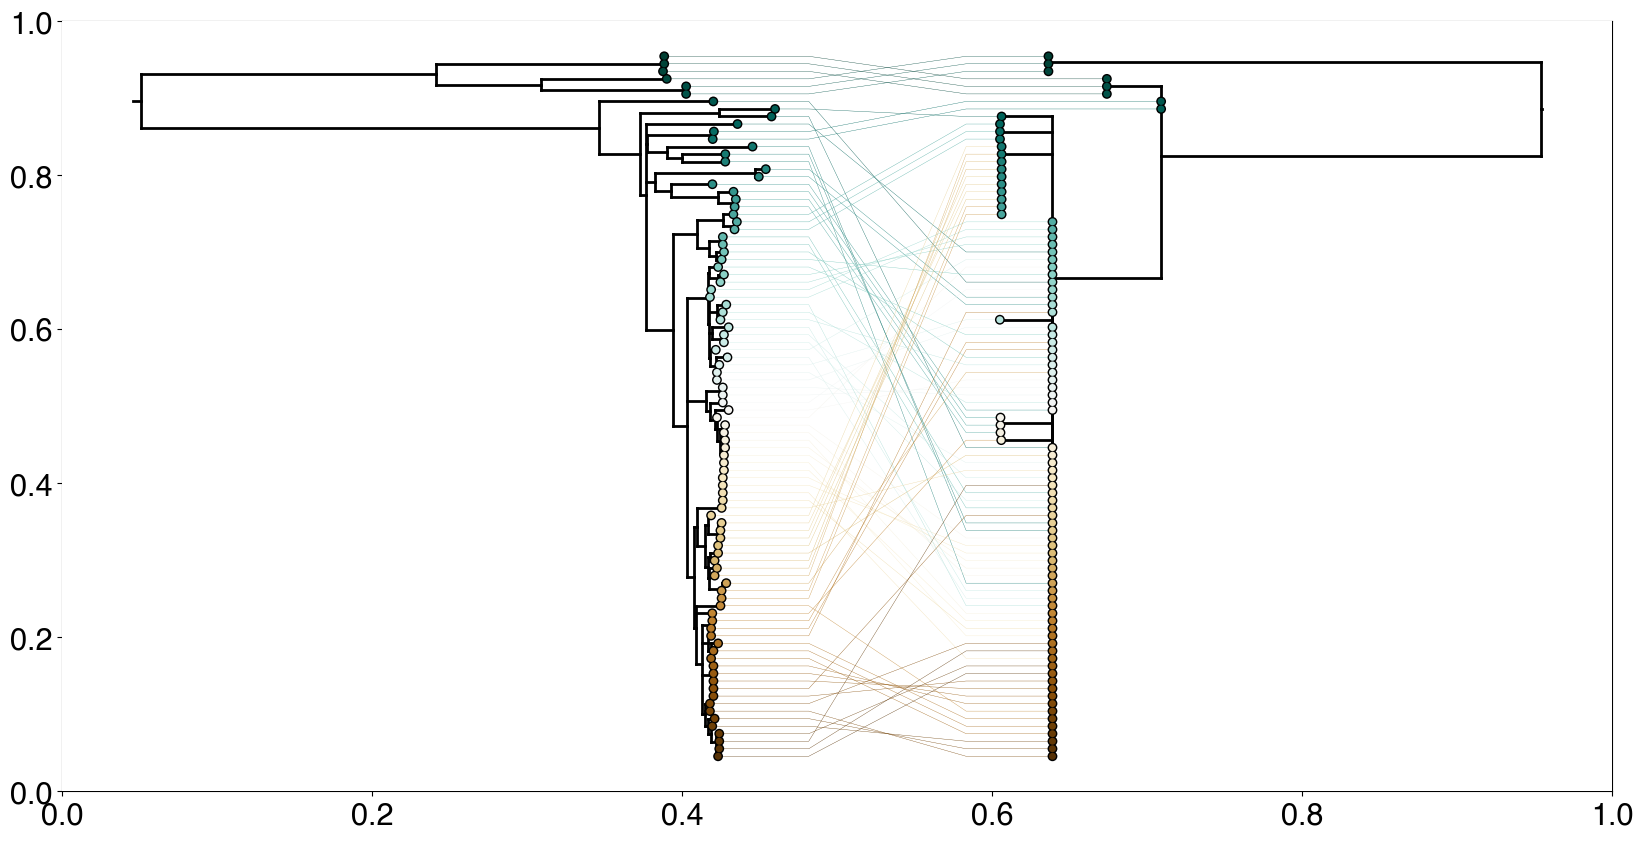

Sson_NC_009347_spC_over90.filtered95


<Figure size 640x480 with 0 Axes>

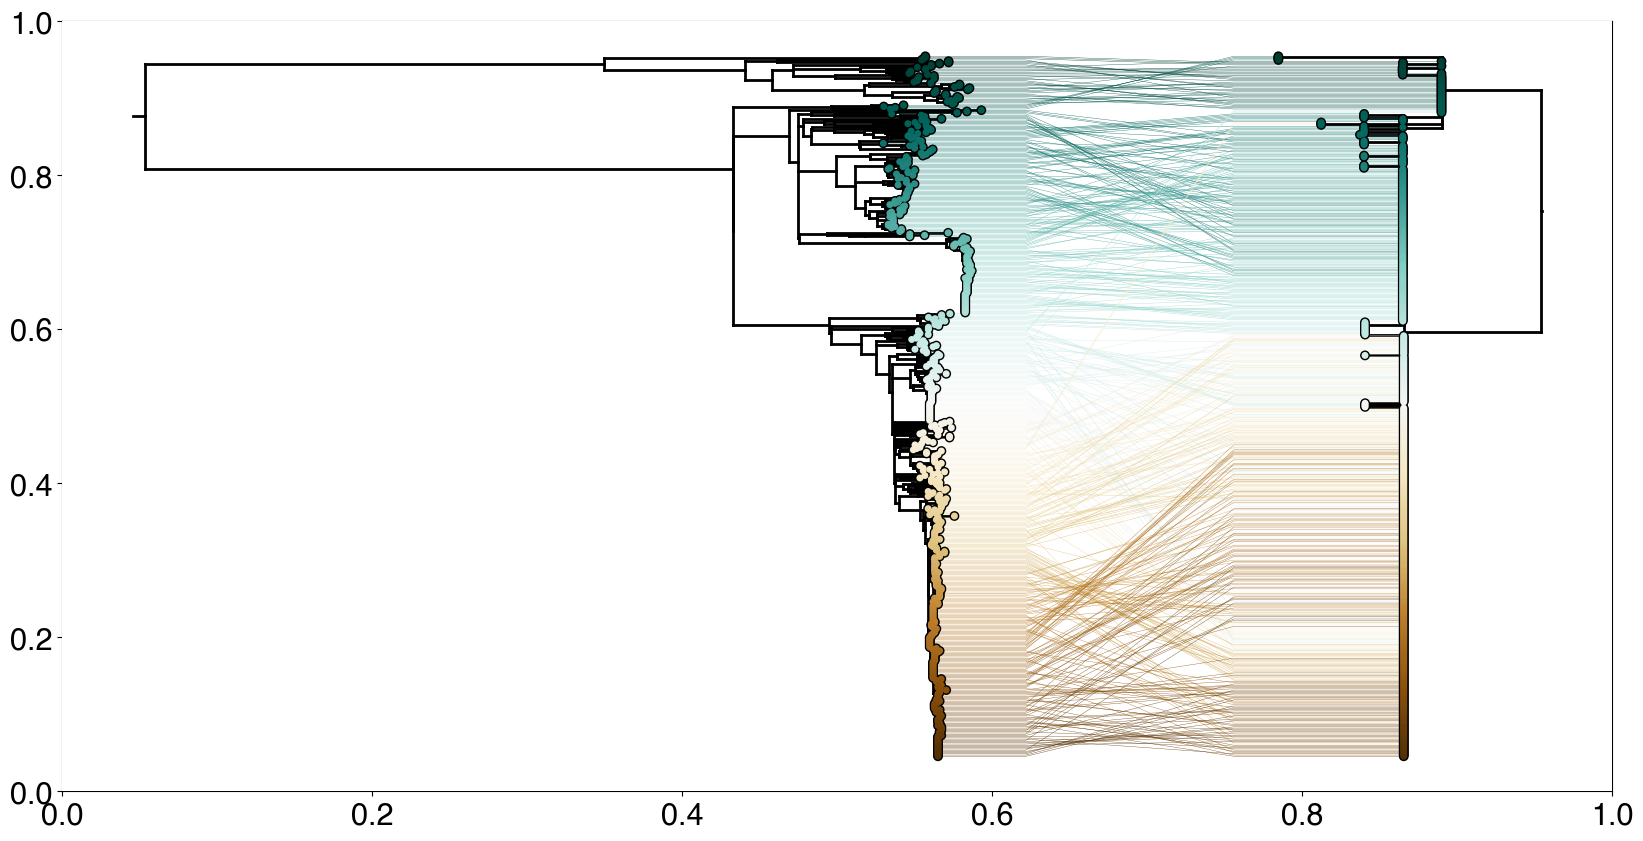

<Figure size 640x480 with 0 Axes>

In [12]:
chromosome_tree_node_scale=10

for filename in filenames:

    fig = plt.subplots(figsize=(20,10),facecolor='w')

    gs = GridSpec(1, 1,hspace=0.0,wspace=0.0)
    ax = plt.subplot(gs[0])

    print(filename)

    tree1=trees[filename + '_chromosome']
    tree2=trees[filename]

    cmap=mpl.cm.BrBG
    x_attr1=lambda k: k.height*chromosome_tree_node_scale ## branch x position is determined by height
    c_func='k'
    ct_func=lambda k: cmap(k.y/float(tree1.ySpan)) ## call colour map with fraction that represents the y position of a tip (returns colour)

    tree1.plotTree(ax,x_attr=x_attr1,width=2,colour=c_func) ## plot black tree
    tree1.plotPoints(ax,x_attr=x_attr1,size=25,colour=ct_func,zorder=100) ## plot circles at tips


    skip=tree1.treeHeight*chromosome_tree_node_scale*0.35 ## skip this many units between trees
    x_attr=lambda k: tree1.treeHeight*chromosome_tree_node_scale+skip+tree2.treeHeight-k.height ## for tree2 we'll offset x coordinates by the height of the tree and invert branches
    tree2.plotTree(ax,x_attr=x_attr,width=2,colour=c_func) ## plot black tree
    tree2.plotPoints(ax,x_attr=x_attr,size=25,colour=ct_func,zorder=100) ## plot circles at tips

    for k in filter(lambda x: x.branchType=='leaf',tree1.Objects): ## grab leaf objects in tree1
        x=k.height*chromosome_tree_node_scale ## get height
        y=k.y ## get y position

        # try:
        matching_tip=tree2.getBranches(lambda x: x.branchType=='leaf' and x.name==k.name) ## fetch corresponding branch in tree2
        match_y=matching_tip.y
        xs=[x,tree1.treeHeight*chromosome_tree_node_scale+0.025*skip,tree1.treeHeight*chromosome_tree_node_scale+skip-0.025*skip,x_attr(matching_tip)] ## x coordinates for tangleline
        ys=[y,y,match_y,match_y] ## y coordinates for tangleline
        ax.plot(xs,ys,color=cmap(y/float(tree1.ySpan)), linewidth=0.25) ## plot tangleline

        # except Exception as e:
        #     print('corresponding tip not found')
            
    
    # Set up axes: remove ticks and spines right after creating the axes
    ax.set_xticks([])  # Remove x-axis tick marks
    ax.set_yticks([])  # Remove y-axis tick marks
    ax.spines['top'].set_visible(False)  # Remove top spine
    ax.spines['right'].set_visible(False)  # Remove right spine
    ax.spines['left'].set_visible(False)  # Remove left spine
    ax.spines['bottom'].set_visible(False)  # Remove bottom spine

        
    plt.show()
    # save the figure
    plt.savefig('../../../../Plasmids-Text/Figures/tangle_tree_'+filename+'.pdf',bbox_inches='tight',dpi=300)
